# 02 Exploratory Data Analysis
Create descriptive statistics and distributions for pH, TDS, and water temperature only.

In [4]:

from pathlib import Path
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().parent
os.chdir(PROJECT_ROOT)

print("Working directory:", Path.cwd())


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.data_preprocessing import load_data

df = load_data("data/processed/water_quality_clean.csv")

df.head()


Working directory: /Users/jakobsmacncheese/Desktop/ISU/VRO-Project
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118286 entries, 0 to 118285
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            118286 non-null  int64         
 1   created_date  118286 non-null  datetime64[ns]
 2   water_pH      118286 non-null  float64       
 3   TDS           118286 non-null  int64         
 4   water_temp    118286 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 4.5 MB
None


,id,created_date,water_pH,TDS,water_temp
0,181775,2023-01-26 11:24:00,7.60,250,24.00
1,181777,2023-01-26 11:33:00,7.60,247,24.06
2,181778,2023-01-26 12:02:00,7.60,249,24.19
3,181780,2023-01-26 12:05:00,6.92,247,24.19
4,181782,2023-01-26 12:10:00,7.30,245,24.25


In [5]:
from src.visualization import plot_time_series

plot_time_series(
    df,
    column="water_pH",
    path="results/figures/time_series_water_pH.png",
)




In [6]:
plot_time_series(
    df,
    column="TDS",
    path="results/figures/time_series_TDS.png",
)

In [7]:
plot_time_series(
    df,
    column="water_temp",
    path="results/figures/time_series_water_temp.png",
)

In [8]:
from src.visualization import plot_distributions

plot_distributions(
    df,
    directory="results/figures",
)

In [9]:
from src.visualization import plot_correlation_heatmap

plot_correlation_heatmap(
    df,
    path="results/figures/correlation_heatmap.png",
)

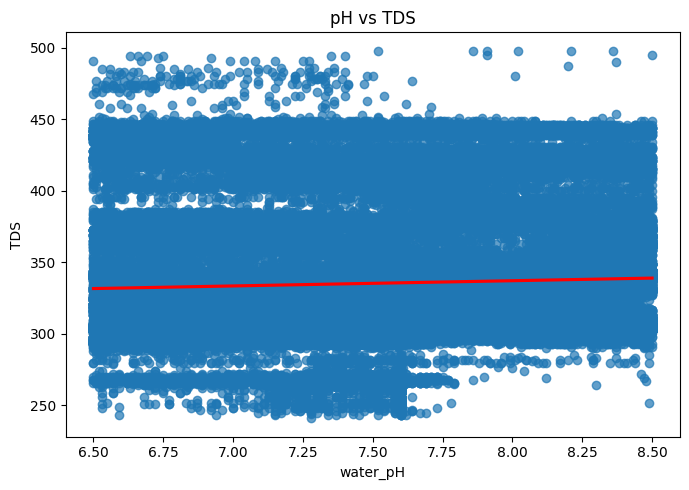

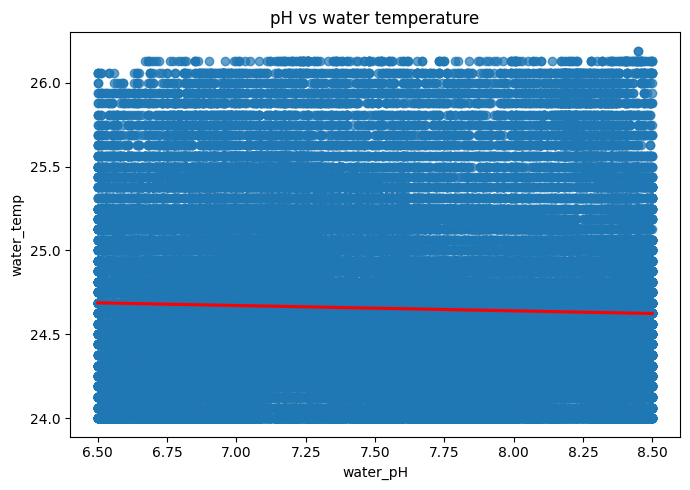

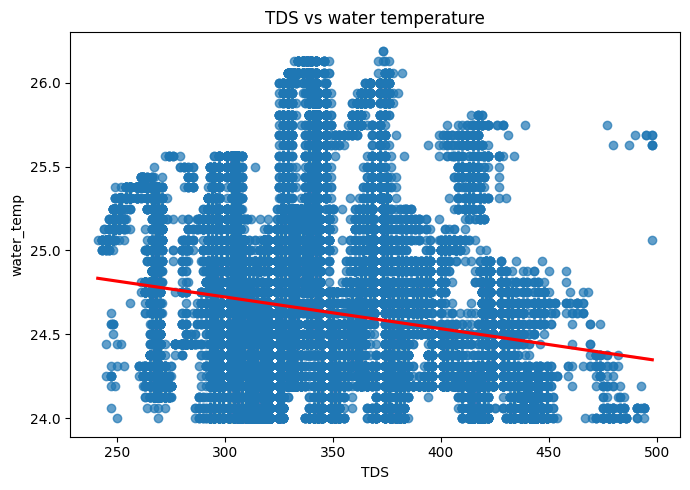

In [10]:
pairs = [
    ("water_pH", "TDS", "pH vs TDS"),
    ("water_pH", "water_temp", "pH vs water temperature"),
    ("TDS", "water_temp", "TDS vs water temperature"),
]

for x_column, y_column, title in pairs:
    figure, axis = plt.subplots(figsize=(7, 5))

    sns.regplot(
        data=df,
        x=x_column,
        y=y_column,
        scatter_kws={"alpha": 0.7},
        line_kws={"color": "red"},
        ax=axis,
    )

    axis.set_title(title)
    axis.set_xlabel(x_column)
    axis.set_ylabel(y_column)

    output_name = f"scatter_{x_column}_vs_{y_column}.png"
    figure.tight_layout()
    figure.savefig(
        Path("results/figures") / output_name,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(figure)

In [14]:
from src.exploratory_analysis import descriptive_statistics

summary = descriptive_statistics(df)
summary

summary.to_csv("results/tables/descriptive_statistics.csv")


from src.visualization import (
    plot_correlation_heatmap,
    plot_distributions,
    plot_time_series,
)

for column in ["water_pH", "TDS", "water_temp"]:
    plot_time_series(
        df,
        column=column,
        path=f"results/figures/time_series_{column}.png",
    )

plot_distributions(df, "results/figures")

plot_correlation_heatmap(
    df,
    "results/figures/correlation_heatmap.png",
)

/var/folders/s3/g3glmdm94pv7z0hqzl99ycc00000gn/T/ipykernel_80373/1595971373.py:32: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_avg = df[[PH_COL, TDS_COL, TEMP_COL]].resample("1H").mean()


                     water_pH         TDS  water_temp
created_date                                         
2023-01-26 11:00:00  7.600000  248.500000   24.030000
2023-01-26 12:00:00  7.383125  248.062500   24.324375
2023-01-26 13:00:00  7.442857  250.857143   24.598571
2023-01-26 14:00:00  7.463229  248.645833   25.056979
2023-01-26 15:00:00  7.406786  250.035714   25.202054


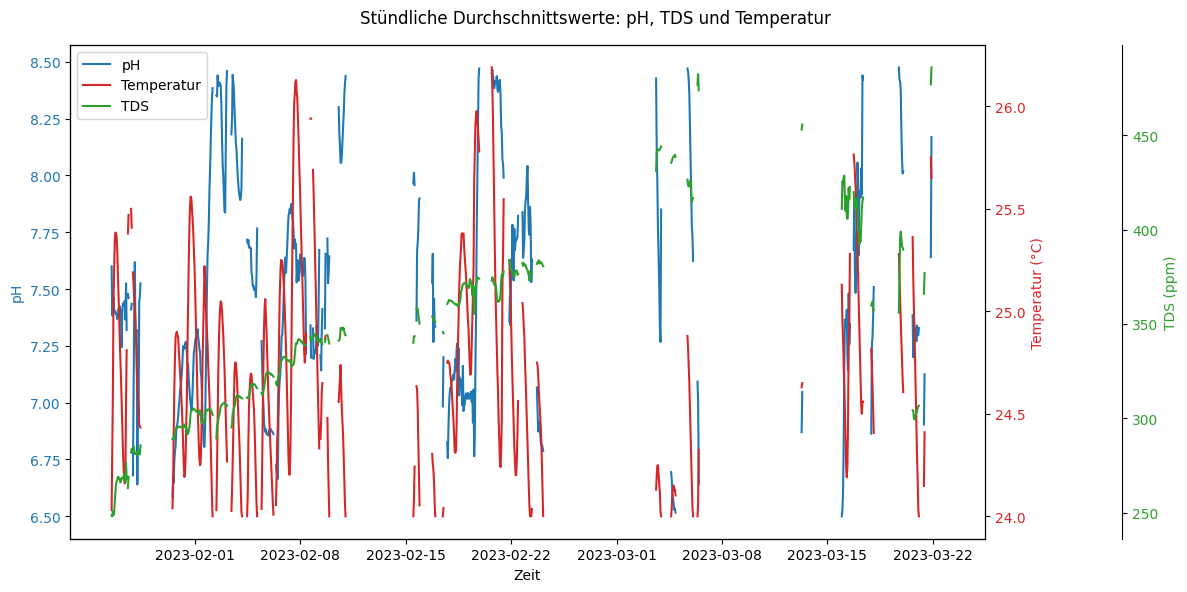

NameError: name 'os' is not defined

In [8]:
"""
Skript: Stündliche Durchschnittswerte von pH, TDS und Temperatur
aus der Wasserqualitäts-CSV berechnen und gemeinsam plotten.

Passe ggf. die Spaltennamen unten an deine CSV an.
"""

import pandas as pd
import matplotlib.pyplot as plt

# ---- 1. Konfiguration: Pfad und Spaltennamen anpassen ----
CSV_PATH = "/Users/jakobsmacncheese/Desktop/ISU/VRO-Project/data/processed/water_quality_clean.csv"

# Name der Zeitstempel-Spalte in deiner CSV
TIME_COL = "created_date"

# Namen der Messwert-Spalten
PH_COL = "water_pH"
TDS_COL = "TDS"
TEMP_COL = "water_temp"

# ---- 2. Daten laden ----
df = pd.read_csv(CSV_PATH)

# Zeitstempel-Spalte in echtes Datetime-Format umwandeln
df[TIME_COL] = pd.to_datetime(df[TIME_COL])

# Zeitstempel als Index setzen (nötig für Resampling)
df = df.set_index(TIME_COL)

# ---- 3. Stündliche Durchschnittswerte berechnen ----
hourly_avg = df[[PH_COL, TDS_COL, TEMP_COL]].resample("1H").mean()

print(hourly_avg.head())

# ---- 4. Plot: alle drei Größen in einem Diagramm ----
fig, ax1 = plt.subplots(figsize=(12, 6))

# pH auf linker Achse
color1 = "tab:blue"
ax1.set_xlabel("Zeit")
ax1.set_ylabel("pH", color=color1)
ax1.plot(hourly_avg.index, hourly_avg[PH_COL], color=color1, label="pH")
ax1.tick_params(axis="y", labelcolor=color1)

# Temperatur auf einer zweiten y-Achse (rechts)
ax2 = ax1.twinx()
color2 = "tab:red"
ax2.set_ylabel("Temperatur (°C)", color=color2)
ax2.plot(hourly_avg.index, hourly_avg[TEMP_COL], color=color2, label="Temperatur")
ax2.tick_params(axis="y", labelcolor=color2)

# TDS auf einer dritten y-Achse (weiter rechts verschoben)
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("axes", 1.15))
color3 = "tab:green"
ax3.set_ylabel("TDS (ppm)", color=color3)
ax3.plot(hourly_avg.index, hourly_avg[TDS_COL], color=color3, label="TDS")
ax3.tick_params(axis="y", labelcolor=color3)

fig.suptitle("Stündliche Durchschnittswerte: pH, TDS und Temperatur")
fig.tight_layout()

# Legende zusammenführen
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc="upper left")

plt.savefig("hourly_water_quality_plot.png", dpi=150)
plt.show()




              water_pH         TDS  water_temp
created_date                                  
2023-01-26    7.398749  264.450000   25.212620
2023-01-27    7.416332  268.549849   24.444451
2023-01-28    7.435730  282.101124   24.554532
2023-01-29         NaN         NaN         NaN
2023-01-30    6.936746  294.964269   24.818652


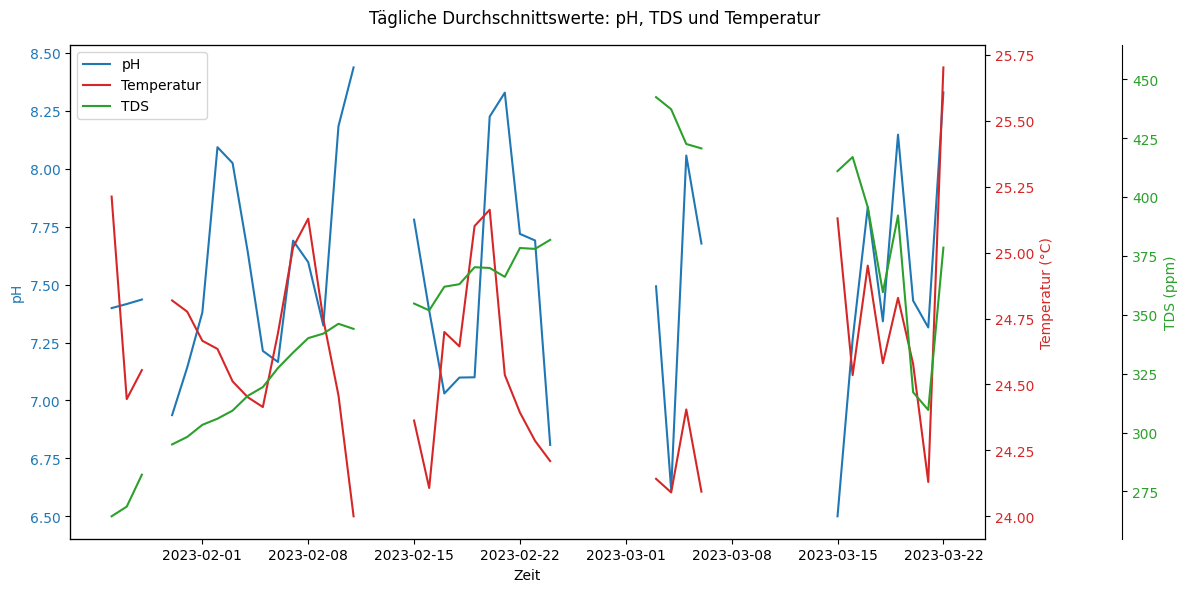

NameError: name 'os' is not defined

In [9]:
"""
Skript: Tägliche Durchschnittswerte von pH, TDS und Temperatur
aus der Wasserqualitäts-CSV berechnen und gemeinsam plotten.

Passe ggf. die Spaltennamen unten an deine CSV an.
"""

import pandas as pd
import matplotlib.pyplot as plt

# ---- 1. Konfiguration: Pfad und Spaltennamen anpassen ----
CSV_PATH = "/Users/jakobsmacncheese/Desktop/ISU/VRO-Project/data/processed/water_quality_clean.csv"

# Name der Zeitstempel-Spalte in deiner CSV
TIME_COL = "created_date"

# Namen der Messwert-Spalten
PH_COL = "water_pH"
TDS_COL = "TDS"
TEMP_COL = "water_temp"

# ---- 2. Daten laden ----
df = pd.read_csv(CSV_PATH)

# Zeitstempel-Spalte in echtes Datetime-Format umwandeln
df[TIME_COL] = pd.to_datetime(df[TIME_COL])

# Zeitstempel als Index setzen (nötig für Resampling)
df = df.set_index(TIME_COL)

# ---- 3. Tägliche Durchschnittswerte berechnen ----
daily_avg = df[[PH_COL, TDS_COL, TEMP_COL]].resample("1D").mean()

print(daily_avg.head())

# ---- 4. Plot: alle drei Größen in einem Diagramm ----
fig, ax1 = plt.subplots(figsize=(12, 6))

# pH auf linker Achse
color1 = "tab:blue"
ax1.set_xlabel("Zeit")
ax1.set_ylabel("pH", color=color1)
ax1.plot(daily_avg.index, daily_avg[PH_COL], color=color1, label="pH")
ax1.tick_params(axis="y", labelcolor=color1)

# Temperatur auf einer zweiten y-Achse (rechts)
ax2 = ax1.twinx()
color2 = "tab:red"
ax2.set_ylabel("Temperatur (°C)", color=color2)
ax2.plot(daily_avg.index, daily_avg[TEMP_COL], color=color2, label="Temperatur")
ax2.tick_params(axis="y", labelcolor=color2)

# TDS auf einer dritten y-Achse (weiter rechts verschoben)
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("axes", 1.15))
color3 = "tab:green"
ax3.set_ylabel("TDS (ppm)", color=color3)
ax3.plot(daily_avg.index, daily_avg[TDS_COL], color=color3, label="TDS")
ax3.tick_params(axis="y", labelcolor=color3)

fig.suptitle("Tägliche Durchschnittswerte: pH, TDS und Temperatur")
fig.tight_layout()

# Legende zusammenführen
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc="upper left")

plt.savefig("daily_water_quality_plot.png", dpi=150)
plt.show()



              water_pH         TDS  water_temp
created_date                                  
2023-01-26    7.398749  264.450000   25.212620
2023-01-27    7.416332  268.549849   24.444451
2023-01-28    7.435730  282.101124   24.554532
2023-01-29         NaN         NaN         NaN
2023-01-30    6.936746  294.964269   24.818652


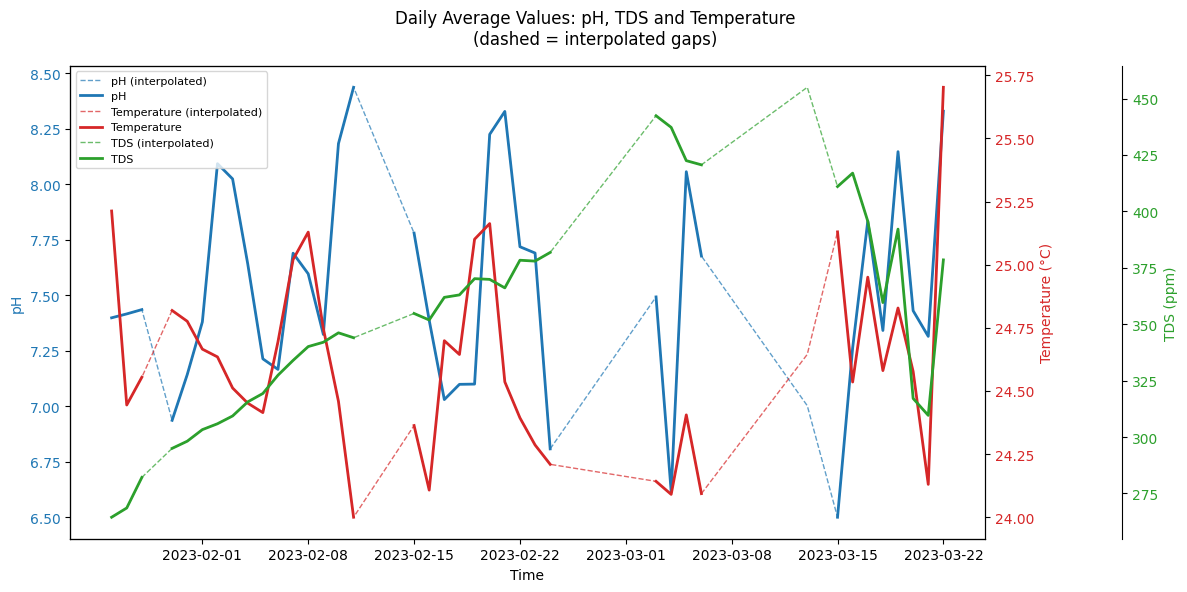

In [15]:
"""
Script: Compute daily average values of pH, TDS and temperature
from the water quality CSV and plot them together.

Adjust the column names below to match your CSV if needed.
"""

import pandas as pd
import matplotlib.pyplot as plt

# ---- 1. Configuration: adjust path and column names ----
CSV_PATH = "/Users/jakobsmacncheese/Desktop/ISU/VRO-Project/data/processed/water_quality_clean.csv"

# Name of the timestamp column in your CSV
TIME_COL = "created_date"

# Names of the measurement columns
PH_COL = "water_pH"
TDS_COL = "TDS"
TEMP_COL = "water_temp"

# ---- 2. Load data ----
df = pd.read_csv(CSV_PATH)

# Convert timestamp column to proper datetime format
df[TIME_COL] = pd.to_datetime(df[TIME_COL])

# Set timestamp as index (required for resampling)
df = df.set_index(TIME_COL)

# ---- 3. Compute daily average values ----
daily_avg = df[[PH_COL, TDS_COL, TEMP_COL]].resample("1D").mean()

print(daily_avg.head())

# ---- 3b. Fill gaps and interpolate ----
# Create a complete, gap-free daily index from first to last day
full_range = pd.date_range(daily_avg.index.min(), daily_avg.index.max(), freq="1D")

# Reindex onto the complete index -> missing days become NaN
daily_full = daily_avg.reindex(full_range)

# Linearly interpolate missing values (only "real" gaps between measurements,
# no extrapolation before the first / after the last measurement)
daily_interp = daily_full.interpolate(method="linear", limit_area="inside")

# ---- 4. Plot: all three variables in one chart ----
fig, ax1 = plt.subplots(figsize=(12, 6))

def plot_with_interpolation(ax, x_interp, y_interp, x_real, y_real, color, label):
    """Draws the interpolated line dashed and overlays the real
    measurements as a solid line (gaps remain visibly broken in the
    solid line, so only the dashed interpolation is visible there)."""
    ax.plot(x_interp, y_interp, color=color, linestyle="--", linewidth=1,
             alpha=0.7, label=f"{label} (interpolated)")
    ax.plot(x_real, y_real, color=color, linestyle="-", linewidth=2, label=label)

# pH on the left axis
color1 = "tab:blue"
ax1.set_xlabel("Time")
ax1.set_ylabel("pH", color=color1)
plot_with_interpolation(ax1, daily_interp.index, daily_interp[PH_COL],
                         daily_full.index, daily_full[PH_COL], color1, "pH")
ax1.tick_params(axis="y", labelcolor=color1)

# Temperature on a second y-axis (right)
ax2 = ax1.twinx()
color2 = "tab:red"
ax2.set_ylabel("Temperature (\u00b0C)", color=color2)
plot_with_interpolation(ax2, daily_interp.index, daily_interp[TEMP_COL],
                         daily_full.index, daily_full[TEMP_COL], color2, "Temperature")
ax2.tick_params(axis="y", labelcolor=color2)

# TDS on a third y-axis (shifted further right)
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("axes", 1.15))
color3 = "tab:green"
ax3.set_ylabel("TDS (ppm)", color=color3)
plot_with_interpolation(ax3, daily_interp.index, daily_interp[TDS_COL],
                         daily_full.index, daily_full[TDS_COL], color3, "TDS")
ax3.tick_params(axis="y", labelcolor=color3)

fig.suptitle("Daily Average Values: pH, TDS and Temperature\n(dashed = interpolated gaps)")
fig.tight_layout()

# Merge legend (real + interpolated lines per variable)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3,
           loc="upper left", fontsize=8)

OUTPUT_DIR = "/Users/jakobsmacncheese/Desktop/ISU/VRO-Project/results/figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.savefig(os.path.join(OUTPUT_DIR, "daily_water_quality_plot.png"), dpi=300)
plt.show()


In [16]:
"""
Script: Compute summary statistics (Minimum, Maximum, Mean, Hourly Deviation)
for water temperature, pH and TDS from the water quality CSV.

"Hourly Deviation" here = the standard deviation of the hourly-averaged
values, i.e. how much the hourly means fluctuate over time.
If you instead want the *average within-hour* variability (spread of raw
readings inside each hour, then averaged across hours), see the
alternative calculation commented below.
"""

import os
import pandas as pd

# ---- 1. Configuration: adjust path and column names ----
CSV_PATH = "/Users/jakobsmacncheese/Desktop/ISU/VRO-Project/data/processed/water_quality_clean.csv"

# Name of the timestamp column in your CSV
TIME_COL = "created_date"

# Names of the measurement columns
PH_COL = "water_pH"
TDS_COL = "TDS"
TEMP_COL = "water_temp"

# ---- 2. Load data ----
df = pd.read_csv(CSV_PATH)
df[TIME_COL] = pd.to_datetime(df[TIME_COL])
df = df.set_index(TIME_COL)

cols = {
    "Water temperature (°C)": TEMP_COL,
    "pH": PH_COL,
    "TDS (ppm)": TDS_COL,
}

# ---- 3. Hourly averages (needed for "Hourly Deviation") ----
hourly_avg = df[[TEMP_COL, PH_COL, TDS_COL]].resample("1H").mean()

# ---- 4. Build the summary table ----
rows = []
for label, col in cols.items():
    minimum = df[col].min()
    maximum = df[col].max()
    mean = df[col].mean()

    # Hourly Deviation = std of the hourly-averaged values
    hourly_deviation = hourly_avg[col].std()

    # --- Alternative: average within-hour standard deviation instead ---
    # hourly_deviation = df[col].groupby(df.index.floor("H")).std().mean()

    rows.append({
        "Parameter": label,
        "Minimum": round(minimum, 2),
        "Maximum": round(maximum, 2),
        "Mean": round(mean, 2),
        "Hourly Deviation": round(hourly_deviation, 2),
    })

summary = pd.DataFrame(rows).set_index("Parameter")

print(summary)

# ---- 5. Save table as CSV ----
OUTPUT_DIR = "/Users/jakobsmacncheese/Desktop/ISU/VRO-Project/results/figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)
summary.to_csv(os.path.join(OUTPUT_DIR, "water_quality_summary.csv"))

                        Minimum  Maximum    Mean  Hourly Deviation
Parameter                                                         
Water temperature (°C)     24.0    26.19   24.66              0.51
pH                          6.5     8.50    7.51              0.50
TDS (ppm)                 241.0   498.00  335.42             46.75


/var/folders/s3/g3glmdm94pv7z0hqzl99ycc00000gn/T/ipykernel_80373/3525153521.py:38: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_avg = df[[TEMP_COL, PH_COL, TDS_COL]].resample("1H").mean()


In [17]:
prediction_path = Path(
    "/Users/jakobsmacncheese/Desktop/ISU/VRO-Project/data/processed/TDS_prediction_0_30C.csv"
)
output_path = Path(OUTPUT_DIR) / "measured_TDS_and_prediction_data.csv"

measured_tds = pd.read_csv(
    CSV_PATH,
    usecols=[TIME_COL, TDS_COL],
).rename(columns={TDS_COL: "measured_TDS"})

prediction_data = pd.read_csv(prediction_path)

# Merge by timestamp when available; otherwise combine rows by position.
prediction_time_col = next(
    (column for column in [TIME_COL, "timestamp", "date", "datetime"]
     if column in prediction_data.columns),
    None,
)

if prediction_time_col is not None:
    measured_tds[TIME_COL] = pd.to_datetime(
        measured_tds[TIME_COL], errors="coerce"
    )
    prediction_data[prediction_time_col] = pd.to_datetime(
        prediction_data[prediction_time_col], errors="coerce"
    )

    if prediction_time_col != TIME_COL:
        prediction_data = prediction_data.rename(
            columns={prediction_time_col: TIME_COL}
        )

    combined_data = prediction_data.merge(
        measured_tds,
        on=TIME_COL,
        how="outer",
    )
else:
    combined_data = pd.concat(
        [measured_tds.reset_index(drop=True),
         prediction_data.reset_index(drop=True)],
        axis=1,
    )

combined_data.to_csv(output_path, index=False)

print(f"Saved {len(combined_data)} rows to:")
print(output_path)

NameError: name 'Path' is not defined